Step 0 — Load Data

In [1]:
import pandas as pd
import numpy as np
import ast

df = pd.read_csv("data/dataset.csv")

print(df.shape)
df.head()

(298450, 24)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


Step 1 — Apply Validation Filter

In [2]:
valid_df = df[
    df["validation_status"].isna() |
    (df["validation_status"] == "approved")
].copy()

print("Original:", len(df))
print("Filtered:", len(valid_df))

Original: 298450
Filtered: 240654


Step 2 — Parse Timestamps

In [3]:
date_cols = [
    "created_datetime",
    "modified_datetime",
    "validation_timestamp"
]

for col in date_cols:
    if col in valid_df.columns:
        valid_df[col] = pd.to_datetime(
            valid_df[col],
            errors="coerce",
            utc=True
        ).dt.tz_localize(None)

valid_df[date_cols].head()

,created_datetime,modified_datetime,validation_timestamp
0,2023-11-20 00:28:46,2023-11-28 04:48:04.582978,2023-11-30 03:08:24.818
1,2023-11-24 22:46:46,2023-11-24 23:00:24.115257,NaT
2,2023-11-20 00:27:46,2023-11-28 04:47:02.337760,2023-11-30 03:08:56.998
3,2023-11-16 06:47:46,2023-11-18 04:46:57.216868,2023-11-18 23:35:12.428
4,2023-11-22 04:56:46,2023-11-28 02:44:50.467370,2023-11-30 03:11:32.796


Step 3 — Parse Violation Lists

In [4]:
valid_df["violations_list"] = valid_df[
    "violation_type"
].apply(
    lambda x: ast.literal_eval(x)
    if pd.notna(x)
    else []
)

In [5]:
valid_df[
    ["violation_type","violations_list"]
].head()

,violation_type,violations_list
0,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[WRONG PARKING, PARKING NEAR ROAD CROSSING]"
1,"[""NO PARKING""]",[NO PARKING]
2,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[WRONG PARKING, PARKING IN A MAIN ROAD]"
3,"[""NO PARKING""]",[NO PARKING]
4,"[""NO PARKING""]",[NO PARKING]


Step 4 — Create Number of Violations Feature

In [6]:
valid_df["num_violations"] = (
    valid_df["violations_list"]
    .apply(len)
)

valid_df["num_violations"].value_counts()

num_violations
1     209073
2      26252
3       4026
4        886
5        222
6        135
7         33
8         15
9         11
11         1
Name: count, dtype: int64

Step 5 — Severity Mapping

In [7]:
severity_map = {
    "NO PARKING":1,
    "WRONG PARKING":2,
    "PARKING ON FOOTPATH":3,
    "DOUBLE PARKING":4,
    "PARKING IN A MAIN ROAD":5,
    "PARKING NEAR ROAD CROSSING":6,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS":7
}

In [8]:
valid_df["max_severity"] = (
    valid_df["violations_list"]
    .apply(
        lambda v:
        max(
            [severity_map.get(x,1) for x in v]
        )
        if len(v)>0
        else 1
    )
)

valid_df["max_severity"].describe()

count    240654.000000
mean          1.852527
std           1.112796
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           7.000000
Name: max_severity, dtype: float64

Step 6 — Vehicle Weight Mapping

In [9]:
vehicle_weight = {
    "SCOOTER":1.0,
    "MOPED":1.0,
    "MOTOR CYCLE":1.0,

    "CAR":1.5,
    "JEEP":1.5,
    "OTHERS":1.5,

    "PASSENGER AUTO":1.8,
    "GOODS AUTO":1.8,

    "VAN":2.0,
    "MAXI-CAB":2.0,

    "TEMPO":2.5,
    "LGV":2.5,

    "MINI LORRY":3.0,
    "TRACTOR":3.0,

    "PRIVATE BUS":3.5,
    "TOURIST BUS":3.5,
    "SCHOOL VEHICLE":3.5,
    "FACTORY BUS":3.5,
    "BUS (BMTC/KSRTC)":3.5,

    "HGV":4.0,
    "TANKER":4.0,
    "LORRY/GOODS VEHICLE":4.0
}

In [10]:
valid_df["vehicle_weight"] = (
    valid_df["vehicle_type"]
    .map(vehicle_weight)
    .fillna(1.5)
)

valid_df[
    ["vehicle_type","vehicle_weight"]
].sample(10)

,vehicle_type,vehicle_weight
92007,SCOOTER,1.0
210272,CAR,1.5
81376,SCOOTER,1.0
213357,MOTOR CYCLE,1.0
268947,CAR,1.5
247898,CAR,1.5
19830,MAXI-CAB,2.0
245914,MOTOR CYCLE,1.0
78756,JEEP,1.5
165159,PASSENGER AUTO,1.8


Step 7 — Junction Weight

In [11]:
junction_counts = (
    valid_df["junction_name"]
    .value_counts()
)

# Normalize
junction_weight = (
    junction_counts
    /
    junction_counts.max()
)

# Apply
valid_df["junction_weight"] = (
    valid_df["junction_name"]
    .map(junction_weight)
)

# Check
valid_df[
    ["junction_name","junction_weight"]
].head()

,junction_name,junction_weight
0,No Junction,1.000000
1,No Junction,1.000000
2,No Junction,1.000000
3,No Junction,1.000000
4,BTP044 - Sagar Theatre Junction,0.074066


In [12]:
# 5 rows are missing junction weights:
valid_df["junction_weight"] = (
    valid_df["junction_weight"]
    .fillna(0)
)

Step 8 — Temporal Features

In [13]:
valid_df["hour"] = (
    valid_df["created_datetime"]
    .dt.hour
)

valid_df["day_of_week"] = (
    valid_df["created_datetime"]
    .dt.day_name()
)

valid_df["month"] = (
    valid_df["created_datetime"]
    .dt.month
)

valid_df["is_weekend"] = (
    valid_df["created_datetime"]
    .dt.dayofweek >= 5
).astype(int)

# Check

valid_df[
    [
        "hour",
        "day_of_week",
        "month",
        "is_weekend"
    ]
].head()

,hour,day_of_week,month,is_weekend
0,0.0,Monday,11.0,0
1,22.0,Friday,11.0,0
2,0.0,Monday,11.0,0
3,6.0,Thursday,11.0,0
4,4.0,Wednesday,11.0,0


Step 9 — Save Engineered Dataset

In [14]:
valid_df.to_csv(
    "engineered_dataset.csv",
    index=False
)

print("Saved")

Saved


# ==========================
# DBSCAN HOTSPOT GENERATION
# ==========================

Step 1 — Extract Coordinates

In [15]:
coords = valid_df[
    ["latitude", "longitude"]
].dropna()

print(coords.shape)

(240654, 2)


Step 2 — Convert to Radians

In [16]:
import numpy as np

coords_rad = np.radians(coords)

Step 3 — K-Distance Plot

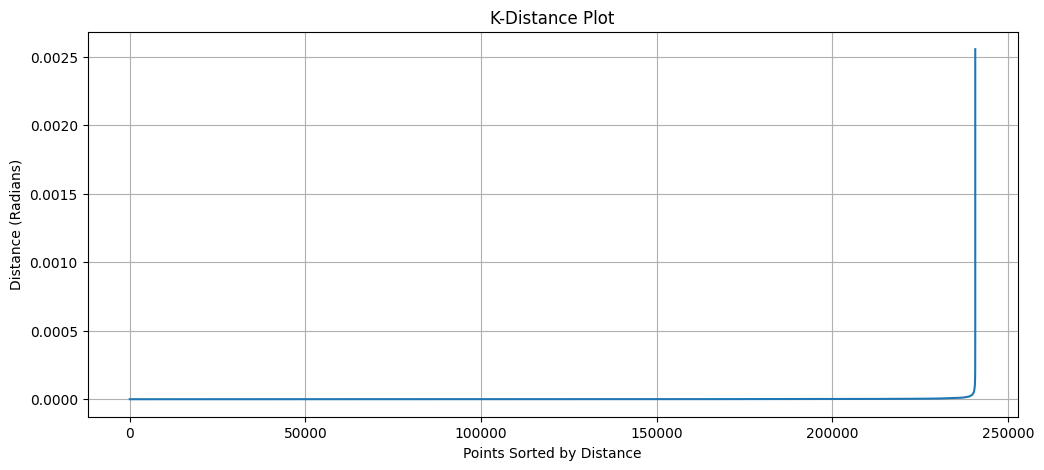

In [17]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(
    n_neighbors=5,
    metric="haversine"
)

neighbors_fit = neighbors.fit(coords_rad)

distances, indices = neighbors_fit.kneighbors(coords_rad)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(12,5))
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Points Sorted by Distance")
plt.ylabel("Distance (Radians)")
plt.grid()
plt.show()

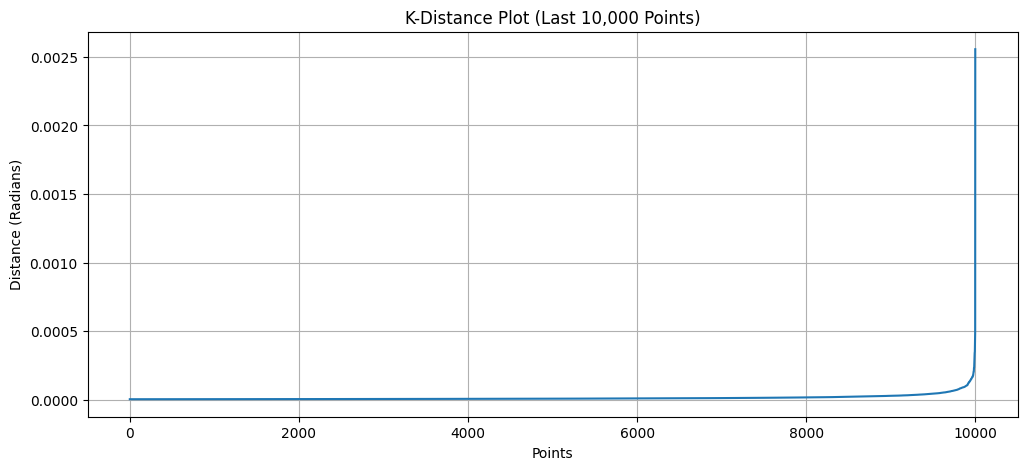

In [18]:
plt.figure(figsize=(12,5))

plt.plot(distances[-10000:])

plt.title("K-Distance Plot (Last 10,000 Points)")
plt.xlabel("Points")
plt.ylabel("Distance (Radians)")
plt.grid()

plt.show()

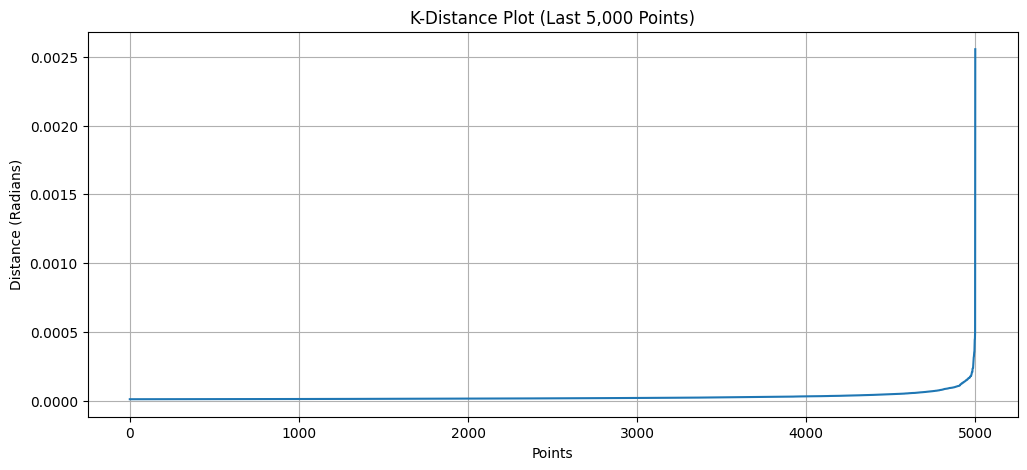

In [19]:
plt.figure(figsize=(12,5))

plt.plot(distances[-5000:])

plt.title("K-Distance Plot (Last 5,000 Points)")
plt.xlabel("Points")
plt.ylabel("Distance (Radians)")
plt.grid()

plt.show()

In [20]:
print("95% :", np.percentile(distances,95))
print("97% :", np.percentile(distances,97))
print("98% :", np.percentile(distances,98))
print("99% :", np.percentile(distances,99))
print("99.5% :", np.percentile(distances,99.5))
print("99.9% :", np.percentile(distances,99.9))

95% : 4.533201671800793e-06
97% : 6.999649940817199e-06
98% : 9.62133332492951e-06
99% : 1.6231540132161048e-05
99.5% : 2.6272320287246268e-05
99.9% : 6.951492496325592e-05


In [21]:
coords.describe()

,latitude,longitude
count,240654.000000,240654.000000
mean,12.980877,77.600111
std,0.049718,0.050162
min,12.802667,77.442553
25%,12.963274,77.571218
50%,12.977304,77.583988
75%,12.997559,77.619966
max,13.293684,77.771735


In [22]:
# DB Scan parameters

eps = 0.00002627      # 99.5 percentile
min_samples = 20

Run DBScan

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.00002627,
    min_samples=20,
    metric="haversine",
    algorithm="ball_tree"
)

clusters = dbscan.fit_predict(coords_rad)

valid_df.loc[coords.index, "cluster_id"] = clusters

First Evaluation

In [24]:
n_clusters = len(
    set(clusters)
) - (1 if -1 in clusters else 0)

noise_pct = (
    (clusters == -1).mean()
) * 100

print("Clusters:", n_clusters)
print("Noise %:", round(noise_pct,2))

Clusters: 255
Noise %: 1.82


Cluster Size Analysis

In [25]:
cluster_sizes = (
    valid_df["cluster_id"]
    .value_counts()
    .sort_values(ascending=False)
)

cluster_sizes.head(20)

cluster_id
 2.0     106314
 3.0      25978
 7.0      14250
 43.0      5129
 4.0       4400
-1.0       4380
 17.0      4136
 50.0      3573
 24.0      3515
 16.0      3180
 15.0      3178
 32.0      3137
 46.0      2973
 65.0      2666
 12.0      2425
 10.0      2185
 55.0      2103
 11.0      1805
 5.0       1666
 33.0      1534
Name: count, dtype: int64

Hotspot Summary

In [26]:
hotspot_summary = (
    valid_df[valid_df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(
        violations=("cluster_id","size"),
        avg_severity=("max_severity","mean"),
        avg_vehicle_weight=("vehicle_weight","mean"),
        avg_junction_weight=("junction_weight","mean")
    )
    .sort_values(
        "violations",
        ascending=False
    )
)

hotspot_summary.head(20)

,violations,avg_severity,avg_vehicle_weight,avg_junction_weight
cluster_id,,,,
2.0,106314,1.685150,1.383185,0.237511
3.0,25978,1.671722,1.374186,0.330941
7.0,14250,2.562175,1.453144,1.000000
43.0,5129,1.749659,1.099942,1.000000
4.0,4400,2.492955,1.476068,1.000000
17.0,4136,2.115812,1.645213,1.000000
50.0,3573,2.364400,1.618220,1.000000
24.0,3515,1.505832,1.328250,0.013161
16.0,3180,3.246226,1.759403,1.000000


In [27]:
from sklearn.cluster import DBSCAN

eps_test = 0.00001623

dbscan_test = DBSCAN(
    eps=0.00000962,
    min_samples=20,
    metric="haversine",
    algorithm="ball_tree"
)

clusters_test = dbscan_test.fit_predict(coords_rad)

print("Clusters:",
      len(set(clusters_test)) - (1 if -1 in clusters_test else 0))

print("Noise %:",
      round((clusters_test == -1).mean()*100,2))

Clusters: 506
Noise %: 6.17


In [28]:
cluster_sizes_test = (
    pd.Series(clusters_test)
    .value_counts()
    .sort_values(ascending=False)
)

cluster_sizes_test.head(20)

 2      48260
 3      19247
-1      14849
 31      8563
 9       8220
 5       8037
 35      6954
 64      6201
 56      5024
 24      3899
 28      3590
 6       3356
 44      2952
 18      2392
 26      2296
 106     2068
 16      1910
 33      1851
 97      1849
 116     1819
Name: count, dtype: int64

Freeze DBSCAN

In [29]:
valid_df.loc[coords.index, "cluster_id"] = clusters_test

valid_df.to_csv(
    "hotspot_clustered.csv",
    index=False
)

Step 1 — Cluster Density

In [30]:
cluster_stats = (
    valid_df[valid_df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(
        violations=("cluster_id", "size"),
        avg_severity=("max_severity", "mean"),
        avg_vehicle_weight=("vehicle_weight", "mean"),
        avg_junction_weight=("junction_weight", "mean"),
        avg_num_violations=("num_violations", "mean")
    )
)

cluster_stats.head()

,violations,avg_severity,avg_vehicle_weight,avg_junction_weight,avg_num_violations
cluster_id,,,,,
0.0,427,1.119438,1.820375,0.362963,1.030445
1.0,427,2.491803,1.279157,1.000000,1.351288
2.0,48260,1.711148,1.413906,0.073785,1.065499
3.0,19247,1.707591,1.414517,0.259692,1.100327
4.0,1322,1.450076,1.231241,1.000000,1.077912


Step 2 — Persistence Score

In [31]:
valid_df["year_month"] = (
    valid_df["created_datetime"]
    .dt.to_period("M")
)

In [32]:
persistence = (
    valid_df[valid_df["cluster_id"] != -1]
    .groupby("cluster_id")["year_month"]
    .nunique()
    .rename("active_months")
)

cluster_stats = cluster_stats.join(persistence)

Step 3 — Normalize Features

In [33]:
from sklearn.preprocessing import MinMaxScaler

cluster_stats["log_violations"] = np.log1p(
    cluster_stats["violations"]
)

cols = [
    "violations",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_junction_weight",
    "avg_num_violations",
    "active_months"
]

scaler = MinMaxScaler()

cluster_stats[[c + "_norm" for c in cols]] = (
    scaler.fit_transform(
        cluster_stats[cols]
    )
)

cluster_stats["log_violations_norm"] = (
    MinMaxScaler()
    .fit_transform(
        cluster_stats[["log_violations"]]
    )
)

Step 4 — Priority Score

In [34]:
cluster_stats["priority_score"] = (
    0.45 * cluster_stats["log_violations_norm"]
    + 0.20 * cluster_stats["avg_severity_norm"]
    + 0.10 * cluster_stats["avg_vehicle_weight_norm"]
    + 0.10 * cluster_stats["avg_junction_weight_norm"]
    + 0.10 * cluster_stats["active_months_norm"]
    + 0.05 * cluster_stats["avg_num_violations_norm"]
)

Step 5 — Top Hotspots

In [35]:
cluster_stats.sort_values(
    "priority_score",
    ascending=False
).head(20)

,violations,avg_severity,avg_vehicle_weight,avg_junction_weight,avg_num_violations,active_months,log_violations,violations_norm,avg_severity_norm,avg_vehicle_weight_norm,avg_junction_weight_norm,avg_num_violations_norm,active_months_norm,log_violations_norm,priority_score
cluster_id,,,,,,,,,,,,,,,
16.0,1910,3.891623,1.574084,1.000000,1.832984,6,7.555382,0.039358,0.722906,0.289941,1.000000,0.263370,1.0,0.610939,0.661667
114.0,1537,3.797658,1.839493,1.000000,1.936239,6,7.338238,0.031628,0.699414,0.423986,1.000000,0.296017,1.0,0.584776,0.660232
39.0,1542,3.484436,1.885019,1.000000,1.740597,6,7.341484,0.031731,0.621109,0.446980,1.000000,0.234159,1.0,0.585167,0.643953
9.0,8220,2.222993,1.260280,1.000000,1.430900,6,9.014447,0.170138,0.305748,0.131454,1.000000,0.136241,1.0,0.786742,0.635141
6.0,3356,2.640644,1.492193,1.000000,1.338200,6,8.118803,0.069328,0.410161,0.248582,1.000000,0.106931,1.0,0.678826,0.617709
2.0,48260,1.711148,1.413906,0.073785,1.065499,6,10.784379,1.000000,0.177787,0.209043,0.073474,0.020709,1.0,1.000000,0.614845
24.0,3899,2.126699,1.653142,1.000000,1.262118,6,8.268732,0.080582,0.281675,0.329870,1.000000,0.082876,1.0,0.696891,0.607067
35.0,6954,1.586856,1.400374,1.000000,1.014524,6,8.847216,0.143899,0.146714,0.202209,1.000000,0.004592,1.0,0.766592,0.594760
23.0,1623,2.723352,1.682686,1.000000,1.480591,6,7.392648,0.033410,0.430838,0.344791,1.000000,0.151952,1.0,0.591332,0.594344


In [36]:
cluster_stats[
[
    "violations",
    "avg_severity",
    "priority_score"
]
].sort_values(
    "priority_score",
    ascending=False
).head(20)

,violations,avg_severity,priority_score
cluster_id,,,
16.0,1910,3.891623,0.661667
114.0,1537,3.797658,0.660232
39.0,1542,3.484436,0.643953
9.0,8220,2.222993,0.635141
6.0,3356,2.640644,0.617709
2.0,48260,1.711148,0.614845
24.0,3899,2.126699,0.607067
35.0,6954,1.586856,0.594760
23.0,1623,2.723352,0.594344


In [37]:
cluster_stats[
[
    "priority_score",
    "violations",
    "avg_junction_weight",
    "avg_severity"
]
].corr()

,priority_score,violations,avg_junction_weight,avg_severity
priority_score,1.000000,0.296623,0.386508,0.506808
violations,0.296623,1.000000,-0.088981,-0.022983
avg_junction_weight,0.386508,-0.088981,1.000000,0.174318
avg_severity,0.506808,-0.022983,0.174318,1.000000


In [38]:
cluster_centroids = (
    valid_df[valid_df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(
        centroid_lat=("latitude","mean"),
        centroid_lon=("longitude","mean")
    )
)
cluster_centroids.head()

,centroid_lat,centroid_lon
cluster_id,,
0.0,12.925268,77.618743
1.0,12.957341,77.518812
2.0,12.972117,77.577586
3.0,12.981964,77.608047
4.0,12.995539,77.612715


In [39]:
top_station = (
    valid_df[valid_df["cluster_id"] != -1]
    .groupby("cluster_id")["police_station"]
    .agg(lambda x: x.mode().iloc[0])
)
top_station.head()

cluster_id
0.0                  Madiwala
1.0           Byatarayanapura
2.0                  Upparpet
3.0              Shivajinagar
4.0    Pulikeshinagar(F.Town)
Name: police_station, dtype: str

In [40]:
cluster_stats = cluster_stats.drop(
    columns=["centroid_lat","centroid_lon"],
    errors="ignore"
)

cluster_stats = cluster_stats.join(cluster_centroids)

cluster_stats["top_station"] = top_station
cluster_stats.head()

,violations,avg_severity,avg_vehicle_weight,avg_junction_weight,avg_num_violations,active_months,log_violations,violations_norm,avg_severity_norm,avg_vehicle_weight_norm,avg_junction_weight_norm,avg_num_violations_norm,active_months_norm,log_violations_norm,priority_score,centroid_lat,centroid_lon,top_station
cluster_id,,,,,,,,,,,,,,,,,,
0.0,427,1.119438,1.820375,0.362963,1.030445,6,6.059123,0.008622,0.029859,0.414331,0.362749,0.009626,1.0,0.430656,0.377956,12.925268,77.618743,Madiwala
1.0,427,2.491803,1.279157,1.000000,1.351288,6,6.059123,0.008622,0.372951,0.140988,1.000000,0.111069,1.0,0.430656,0.488038,12.957341,77.518812,Byatarayanapura
2.0,48260,1.711148,1.413906,0.073785,1.065499,6,10.784379,1.000000,0.177787,0.209043,0.073474,0.020709,1.0,1.000000,0.614845,12.972117,77.577586,Upparpet
3.0,19247,1.707591,1.414517,0.259692,1.100327,6,9.865162,0.398682,0.176898,0.209352,0.259444,0.031721,1.0,0.889244,0.584005,12.981964,77.608047,Shivajinagar
4.0,1322,1.450076,1.231241,1.000000,1.077912,6,7.187657,0.027172,0.112519,0.116788,1.000000,0.024634,1.0,0.566632,0.490399,12.995539,77.612715,Pulikeshinagar(F.Town)


In [41]:
cluster_stats.columns

Index(['violations', 'avg_severity', 'avg_vehicle_weight',
       'avg_junction_weight', 'avg_num_violations', 'active_months',
       'log_violations', 'violations_norm', 'avg_severity_norm',
       'avg_vehicle_weight_norm', 'avg_junction_weight_norm',
       'avg_num_violations_norm', 'active_months_norm', 'log_violations_norm',
       'priority_score', 'centroid_lat', 'centroid_lon', 'top_station'],
      dtype='str')

In [42]:
cluster_stats[
[
    "violations",
    "avg_severity",
    "priority_score",
    "active_months"
]
].describe()

,violations,avg_severity,priority_score,active_months
count,506.000000,506.000000,506.000000,506.000000
mean,446.254941,1.948933,0.335843,4.972332
std,2459.288733,0.846779,0.112563,1.295547
min,11.000000,1.000000,0.077261,1.000000
25%,31.000000,1.333333,0.254525,4.000000
50%,58.500000,1.766873,0.328867,5.000000
75%,181.500000,2.149366,0.411284,6.000000
max,48260.000000,5.000000,0.661667,6.000000


In [43]:
cluster_stats["risk_level"] = pd.qcut(
    cluster_stats["priority_score"],
    q=[0, 0.50, 0.80, 0.95, 1.0],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)
cluster_stats["risk_level"].value_counts()

risk_level
Low         253
Medium      152
High         75
Critical     26
Name: count, dtype: int64

In [44]:
cluster_stats.to_csv(
    "hotspot_cluster_stats.csv"
)

In [45]:
cluster_stats[
[
    "violations",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_junction_weight",
    "avg_num_violations",
    "active_months",
    "risk_level"
]
].head()

,violations,avg_severity,avg_vehicle_weight,avg_junction_weight,avg_num_violations,active_months,risk_level
cluster_id,,,,,,,
0.0,427,1.119438,1.820375,0.362963,1.030445,6,Medium
1.0,427,2.491803,1.279157,1.000000,1.351288,6,High
2.0,48260,1.711148,1.413906,0.073785,1.065499,6,Critical
3.0,19247,1.707591,1.414517,0.259692,1.100327,6,Critical
4.0,1322,1.450076,1.231241,1.000000,1.077912,6,High
